# QF 627 Programming and Computational Finance
## Problem Set `6` | `Questions`

> Hi, Team. 👋

> Here we go again. The current notebook contains 7 questions that help you review our course content.

> Try to answer questions within a 90-minute time limit (and you may refer to lecture notes and review scripts while you are answering). This kind of timed task will improve your performance and prepare you well for the assessment down the line. Once you complete this, submit your script via eLearn.

> Enjoy!"🤞

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## 👇 Questions 1 to 4 ask you to build, execute, and backtest a `mean-reversion` strategy.

### <font color = blue> 👉 Question 1</font>. Let’s take a look at Google (`GOOGL`) as our security of interest, over the period of August 2011 to July 2020.

### Use a simple moving average of 42 days.

### Set a threshold value at two standard deviations of the current price, to deviate from the simple moving average to signal a positioning.

### <font color = green> NOTE: Your moving threshold value here is NOT an absolute value. You should create two additional columns containing your two standard deviations relative to your base line (a simple moving average of 42 days). </font>

### Visualize your buy and sell positions.

### Below are the lines of code that lead to an answer:

In [3]:
googl = yf.download("GOOGL",
            start = dt.datetime(2011, 8, 1),
            end = dt.datetime(2020, 8, 1),
            auto_adjust = False)

googl = googl["Adj Close"].rename(columns = {"Adj Close": "GOOGL"})

[*********************100%***********************]  1 of 1 completed


In [4]:

googl['sma_42'] = googl['GOOGL'].rolling(window = 42).mean()
googl_two_std = googl['GOOGL'].rolling(window = 42).std()*2
googl['upper_band'] = googl['sma_42'] + googl_two_std
googl['lower_band'] = googl['sma_42'] - googl_two_std

In [5]:
googl

Ticker,GOOGL,sma_42,upper_band,lower_band
Date,,,,
2011-08-01,15.080424,NaN,NaN,NaN
2011-08-02,14.723277,NaN,NaN,NaN
2011-08-03,14.941243,NaN,NaN,NaN
2011-08-04,14.353454,NaN,NaN,NaN
2011-08-05,14.391232,NaN,NaN,NaN
...,...,...,...,...
2020-07-27,75.947678,72.866919,77.812715,67.921124
2020-07-28,74.667519,72.967902,77.882600,68.053203
2020-07-29,75.653702,73.074298,78.024200,68.124396


In [6]:
googl['distance'] = googl['GOOGL'] - googl['sma_42']
googl = googl.dropna()
googl['z_score'] = googl['distance'] / googl['GOOGL'].rolling(window = 42).std()

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_22335/374874079.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  googl['z_score'] = googl['distance'] / googl['GOOGL'].rolling(window = 42).std()


<Axes: xlabel='Date'>

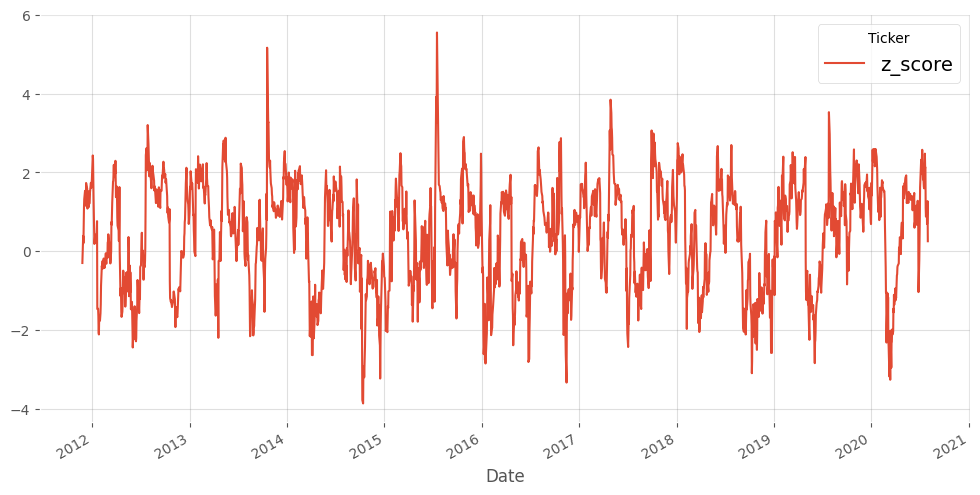

In [7]:
googl[['z_score']].plot(figsize = (12, 6))

In [8]:
from lets_plot import *
LetsPlot.setup_html()

In [9]:
p =\
(
    ggplot(googl.reset_index(),
           aes(x = 'Date', 
               y = 'z_score')) +
    geom_line(color="grey") +
    geom_hline(yintercept = 2, color = "red") +
    geom_hline(yintercept = -2, color = "green") +
    ggsize(1200, 600)
)
p

In [10]:
googl['positions'] =\
(
    np.where(googl['z_score'] > 2, -1,      # short when above 2 sd
    np.where(googl['z_score'] < -2, 1, np.nan))     # long when below -2 sd
)
googl['positions'] =\
(                   # when a z_score crosses zero, close position
    np.where(googl['z_score'] * googl['z_score'].shift(1) < 0, 0,googl['positions'])
)
googl['positions'] =\
(               # forward fill positions
    googl['positions'].ffill()
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_22335/4093602209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  googl['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_22335/4093602209.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  googl['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_22335/4093602209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

<Axes: xlabel='Date'>

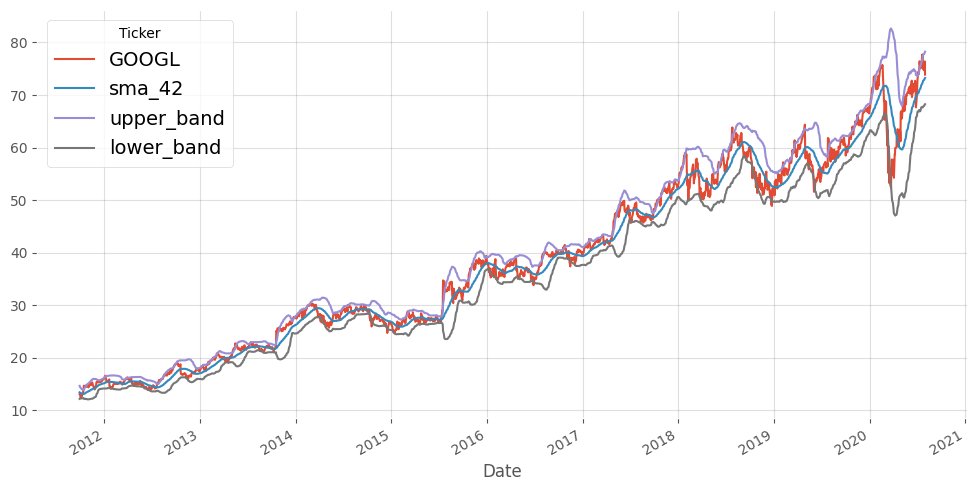

In [11]:
googl[['GOOGL', 'sma_42', 'upper_band', 'lower_band']].plot(figsize = (12, 6))

<Axes: xlabel='Date'>

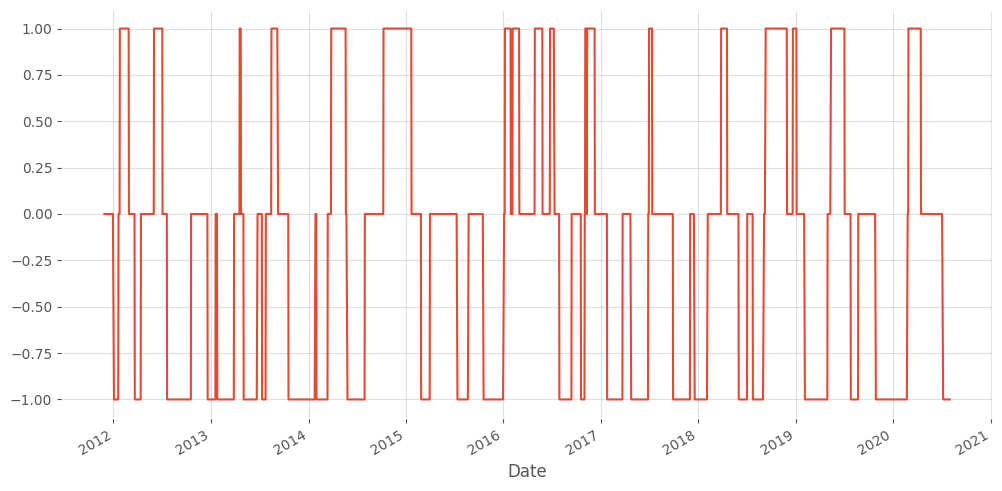

In [12]:
googl['positions'].plot(figsize = (12, 6))

In [13]:
googl

Ticker,GOOGL,sma_42,upper_band,lower_band,distance,z_score,positions
Date,,,,,,,
2011-09-28,13.143579,13.443073,14.676633,12.209514,-0.299494,NaN,NaN
2011-09-29,13.110280,13.396165,14.519511,12.272820,-0.285885,NaN,NaN
2011-09-30,12.800602,13.350387,14.406842,12.293933,-0.549785,NaN,NaN
2011-10-03,12.315460,13.287869,14.266472,12.309265,-0.972408,NaN,NaN
2011-10-04,12.474025,13.243120,14.193542,12.292699,-0.769096,NaN,NaN
...,...,...,...,...,...,...,...
2020-07-27,75.947678,72.866919,77.812715,67.921124,3.080758,1.245809,-1.0
2020-07-28,74.667519,72.967902,77.882600,68.053203,1.699617,0.691647,-1.0
2020-07-29,75.653702,73.074298,78.024200,68.124396,2.579404,1.042204,-1.0


In [14]:
googl_melt = googl.reset_index()
googl_melt = googl_melt.rename(columns={'index':'Date'})

### <font color = red> Answer 1 is presented in the cell below: </font>

In [15]:
p =\
(
    ggplot(googl_melt,
           aes(x = 'Date', 
               y = 'z_score')) +
    geom_line(color="grey") +
    geom_hline(yintercept = 2, color = "red") +
    geom_hline(yintercept = -2, color = "green") +
    geom_line(aes(y = 'positions'), color = "blue") +
    ggsize(1200, 600)
)
p

In [16]:
p =\
(
    ggplot(googl_melt, aes(x = 'Date')) +
    geom_line(aes(y = 'GOOGL'), color = 'grey') +
    geom_line(aes(y = 'upper_band'), color = 'red') +
    geom_line(aes(y = 'lower_band'), color = 'green') +
    geom_point(aes(y = 'GOOGL'), data = googl_melt[googl_melt['positions']==1], color='blue', size = 1.5) +
    geom_point(aes(y = 'GOOGL'), data = googl_melt[googl_melt['positions']==-1], color='orange', size = 1.5) +
    ggsize(1200, 500)
)

p

### <font color = blue> 👉 Question 2</font>. Let’s expand this strategy to two more securities, Apple (`AAPL`) and Amazon (`AMZN`) over the same period of August 2011 to July 2020. 

### When using the strategy above, which of those two securities has the greater Sharpe Ratio?

### Below are the lines of code that lead to an answer:

In [17]:
tickers = ["AAPL", "AMZN"]
df = yf.download(tickers,
            start = dt.datetime(2011, 8, 1),
            end = dt.datetime(2020, 8, 1),
            auto_adjust = False)
df = df["Adj Close"]

[*********************100%***********************]  2 of 2 completed


In [18]:
df.std

<bound method DataFrame.std of Ticker            AAPL        AMZN
Date                              
2011-08-01   11.910486   11.066000
2011-08-02   11.675125   10.585000
2011-08-03   11.784995   10.498000
2011-08-04   11.328689   10.074000
2011-08-05   11.216118   10.135000
...                ...         ...
2020-07-27   92.057396  152.760498
2020-07-28   90.545120  150.016495
2020-07-29   92.280731  151.676498
2020-07-30   93.397339  152.593994
2020-07-31  103.174973  158.233994

[2266 rows x 2 columns]>

In [19]:
df[[ticker + '_z_score' for ticker in tickers]] =\
(df - df.rolling(window=42).mean() )/ df.rolling(window=42).std()

In [20]:
two_std = df[tickers].rolling(window = 42).std()*2

df[[ticker + '_upper_band' for ticker in tickers]] =\
(df[tickers] + two_std)

df[[ticker + '_lower_band' for ticker in tickers]] =\
(df[tickers] - two_std)



In [21]:
df[[ticker + '_positions' for ticker in tickers]] =\
(
    np.where(df[[ticker + '_z_score' for ticker in tickers]] > 2, -1,      # short when above 2 sd
    np.where(df[[ticker + '_z_score' for ticker in tickers]] < -2, 1, np.nan))     # long when below -2 sd
)
df[[ticker + '_positions' for ticker in tickers]] =\
(                   # when a z_score crosses zero, close position
    np.where(df[[ticker + '_z_score' for ticker in tickers]] 
             * df[[ticker + '_z_score' for ticker in tickers]].shift(1) < 0, 0, 
             df[[ticker + '_positions' for ticker in tickers]])
)
df[[ticker + '_positions' for ticker in tickers]] =\
(               # forward fill positions
    df[[ticker + '_positions' for ticker in tickers]].ffill()
)

In [26]:
df[[ticker + '_returns' for ticker in tickers]] =\
np.log(df[tickers] / df[tickers].shift(1))

df[[ticker + '_cum_returns' for ticker in tickers]] =\
df[[ticker + '_returns' for ticker in tickers]].cumsum().apply(np.exp)

In [24]:
df[[ticker + '_strategy_returns' for ticker in tickers]]=\
df[[ticker + '_returns' for ticker in tickers]].values * df[[ticker + '_positions' for ticker in tickers]].shift(1).values

df[[ticker + '_strategy_cum_returns' for ticker in tickers]]=\
df[[ticker + '_strategy_returns' for ticker in tickers]].cumsum().apply(np.exp)

<Axes: xlabel='Date'>

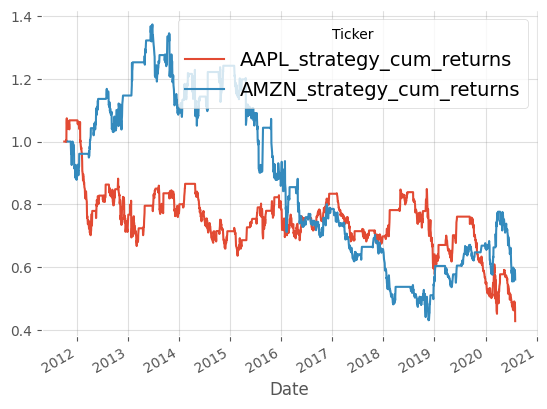

In [25]:
df[[ticker + '_strategy_cum_returns' for ticker in tickers]].plot()

In [34]:
ans = df[[ticker + '_strategy_returns' for ticker in tickers]].mean() / \
      df[[ticker + '_strategy_returns' for ticker in tickers]].std() * np.sqrt(252)
ans

Ticker
AAPL_strategy_returns   -0.412462
AMZN_strategy_returns   -0.280158
dtype: float64

### <font color = red> Answer 2 </font>

    The answer is ____________ .

In [37]:
f'The answer is {ans.index[ans.argmax()]}'

'The answer is AMZN_strategy_returns'

### <font color = blue> 👉 Question 3</font>. Let’s suppose that you started from a `$200,000` capital base for each of the three securities.

### Disregarding commission, how much will you have in the end in your account for each of the securities as a result of the mean-reversion strategy-based trading?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 3 </font>

    GOOGL : ____________ 
    
    AAPL  : ____________ 
     
    AMZN  : ____________ 
    

### <font color = blue> 👉 Question 4</font>. What are the compound annual growth rates of each of the securities, based on the current mean-reversion strategy-based trading? 

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 4 </font>

    GOOGL : ____________ 
    
    AAPL  : ____________ 
     
    AMZN  : ____________ 

## 👇 Questions 5 to 8 ask you to build, execute, and backtest a momentum strategy.

###  <font color = blue> 👉 Question 5. </font> Our securities of interest are Goldman Sachs (`GS`) and JP Morgan Chase (`JPM`) stock. The time period for analysis is from November 2013 to October 2021.

### Here’s our use of the momentum indicator, reflecting the moving averages of stock prices for trend following.

### The two moving windows are 24 days and 58 days.

### Calculate and visualize the maximum drawdowns and the longest drawdown periods for `GS` and `JPM`.

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 5 (`visualization with lets-plot`) is presented in the cell below: </font>

### <font color = red> Answer 5 </font>
    
    As to GS,
    
    The maximum drawdown is about ____________ percentage points.
    The longest drawdown period lasts for _____________ days.
    
    As to JPM,
    
    The maximum drawdown is about ____________ percentage points.
    The longest drawdown period lasts for _____________ days.
    

###  <font color = blue> 👉 Question 6. </font>  If you had started with a capital of $300,000 for each of the three securities, how much would be left in your account after trading according to your above strategies for `GS` and `JPM`?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 6 </font>

    The answer is ____________________________ .

###  <font color = blue> 👉 Question 7. </font> Using the current momentum strategy, how many trading opportunities were there for GS and JPM?

### Below are the lines of code that lead to an answer:

### <font color = red> Answer 7 </font>

    The answer is ____________________________ .

> 💯 “Thank you for putting your efforts into the individual assessment questions” 😊